In [5]:
!pip -q install datasets tokenizers tqdm matplotlib

## 2) Imports and project folders

In [6]:
import os
import math
import json
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE_DIR = "/content/gpt_project"
DATA_DIR = os.path.join(BASE_DIR, "data")
PRETRAIN_DIR = os.path.join(DATA_DIR, "pretrain")
FINETUNE_DIR = os.path.join(DATA_DIR, "finetune")
TOKENIZER_DIR = os.path.join(BASE_DIR, "tokenizer")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

for d in [PRETRAIN_DIR, FINETUNE_DIR, TOKENIZER_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folders created.")

Device: cuda
Folders created.


# 3) Download and prepare pretraining data from TinyStories

This creates:

data/pretrain/data.txt

In [7]:
from datasets import load_dataset

# Load a subset to keep it beginner-friendly and faster
ds = load_dataset("roneneldan/TinyStories", split="train[:5000]")

pretrain_path = os.path.join(PRETRAIN_DIR, "data.txt")

with open(pretrain_path, "w", encoding="utf-8") as f:
    for item in ds:
        text = item["text"].strip().replace("\r", " ")
        f.write(text + "\n\n")

print("Saved pretraining text to:", pretrain_path)
print("File size (MB):", round(os.path.getsize(pretrain_path) / (1024 * 1024), 2))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Saved pretraining text to: /content/gpt_project/data/pretrain/data.txt
File size (MB): 4.0


# 4) Prepare simple SFT dataset

This version uses a handmade beginner-friendly SFT set.
You can later replace it with Alpaca if you want.

It creates:

data/finetune/sft_data.jsonl

In [8]:
sft_examples = [
    {"instruction": "Summarize the text.", "input": "The cat sat on the mat and then went to sleep.", "output": "A cat sat on the mat and fell asleep."},
    {"instruction": "Translate to French.", "input": "Good morning.", "output": "Bonjour."},
    {"instruction": "Write a short poem about rain.", "input": "", "output": "Rain taps softly on the ground, whispering a silver sound."},
    {"instruction": "Answer the question.", "input": "What is the capital of France?", "output": "The capital of France is Paris."},
    {"instruction": "Rewrite the sentence in simpler words.", "input": "The child was ecstatic about the excursion.", "output": "The child was very happy about the trip."},
]

# Expand to 200 by repeating patterns with slight changes
more_examples = []
animals = ["cat", "dog", "rabbit", "bird", "fox"]
places = ["park", "garden", "school", "forest", "village"]
actions = ["ran", "jumped", "slept", "played", "sang"]

for i in range(195):
    animal = random.choice(animals)
    place = random.choice(places)
    action = random.choice(actions)

    more_examples.append({
        "instruction": "Summarize the text.",
        "input": f"The {animal} went to the {place}. It {action} there for a while and then returned home happily.",
        "output": f"A {animal} visited the {place}, {action} there, and went home happy."
    })

sft_examples.extend(more_examples)

sft_path = os.path.join(FINETUNE_DIR, "sft_data.jsonl")
with open(sft_path, "w", encoding="utf-8") as f:
    for ex in sft_examples:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print("Saved SFT data to:", sft_path)
print("Number of examples:", len(sft_examples))

Saved SFT data to: /content/gpt_project/data/finetune/sft_data.jsonl
Number of examples: 200


#5) Train a BPE tokenizer

This creates:

tokenizer/tokenizer.json

In [9]:
tokenizer_path = os.path.join(TOKENIZER_DIR, "tokenizer.json")

tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()
tokenizer.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=4000,
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer.train([pretrain_path], trainer)
tokenizer.save(tokenizer_path)

print("Tokenizer saved to:", tokenizer_path)
print("Vocab size:", tokenizer.get_vocab_size())

Tokenizer saved to: /content/gpt_project/tokenizer/tokenizer.json
Vocab size: 4000


#6) Load tokenizer and helper functions

In [10]:
tokenizer = Tokenizer.from_file(tokenizer_path)

PAD_ID = tokenizer.token_to_id("[PAD]")
UNK_ID = tokenizer.token_to_id("[UNK]")
BOS_ID = tokenizer.token_to_id("[BOS]")
EOS_ID = tokenizer.token_to_id("[EOS]")

def encode_text(text, add_bos=False, add_eos=False):
    ids = tokenizer.encode(text).ids
    if add_bos:
        ids = [BOS_ID] + ids
    if add_eos:
        ids = ids + [EOS_ID]
    return ids

def decode_ids(ids):
    return tokenizer.decode(ids)

#7) Read pretraining text and tokenize it

In [11]:
with open(pretrain_path, "r", encoding="utf-8") as f:
    text = f.read()

all_ids = encode_text(text, add_bos=False, add_eos=False)
print("Total tokens:", len(all_ids))

split_idx = int(0.9 * len(all_ids))
train_ids = all_ids[:split_idx]
val_ids = all_ids[split_idx:]

print("Train tokens:", len(train_ids))
print("Val tokens:", len(val_ids))

Total tokens: 1077766
Train tokens: 969989
Val tokens: 107777


#8) Create dataset for pretraining

In [12]:
class NextTokenDataset(Dataset):
    def __init__(self, token_ids, block_size):
        self.token_ids = token_ids
        self.block_size = block_size

    def __len__(self):
        return len(self.token_ids) - self.block_size - 1

    def __getitem__(self, idx):
        x = torch.tensor(self.token_ids[idx:idx + self.block_size], dtype=torch.long)
        y = torch.tensor(self.token_ids[idx + 1:idx + self.block_size + 1], dtype=torch.long)
        return x, y

block_size = 128
batch_size = 32

train_dataset = NextTokenDataset(train_ids, block_size)
val_dataset = NextTokenDataset(val_ids, block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 30308
Val batches: 3364


#9) Build GPT model from scratch

In [13]:
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 128
    n_embd: int = 128
    n_head: int = 4
    n_layer: int = 4
    dropout: float = 0.1

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.n_head = config.n_head
        self.head_dim = config.n_embd // config.n_head

        self.qkv = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.proj = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        mask = torch.tril(torch.ones(config.block_size, config.block_size))
        self.register_buffer("mask", mask.view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = torch.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        y = self.resid_dropout(self.proj(y))
        return y

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.ffwd = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)

        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size, "Sequence too long"

        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        tok = self.token_emb(idx)
        pos = self.pos_emb(pos)
        x = self.drop(tok + pos)

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=50, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")

            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx

config = GPTConfig(
    vocab_size=tokenizer.get_vocab_size(),
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.1
)

model = GPT(config).to(DEVICE)
print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Model parameters: 1.833728 M


#10) Training helpers

In [14]:
def evaluate(model, loader, max_batches=100):
    model.eval()
    losses = []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= max_batches:
                break
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, loss = model(x, y)
            losses.append(loss.item())
    return sum(losses) / len(losses)

def train_model(model, train_loader, val_loader, epochs=3, lr=3e-4, ckpt_name="pretrained.pt"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            _, loss = model(x, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            pbar.set_postfix(loss=loss.item())

        val_loss = evaluate(model, val_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}: val_loss = {val_loss:.4f}")

        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, ckpt_name))

    return train_losses, val_losses

#11) Pretrain the model

In [15]:
pretrain_train_losses, pretrain_val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=3,
    lr=3e-4,
    ckpt_name="pretrained.pt"
)

Epoch 1/3:   0%|          | 0/30308 [00:00<?, ?it/s]

Epoch 1: val_loss = 2.6841


Epoch 2/3:   0%|          | 0/30308 [00:00<?, ?it/s]

Epoch 2: val_loss = 2.6895


Epoch 3/3:   0%|          | 0/30308 [00:00<?, ?it/s]

Epoch 3: val_loss = 2.7113


#12) Plot pretraining loss

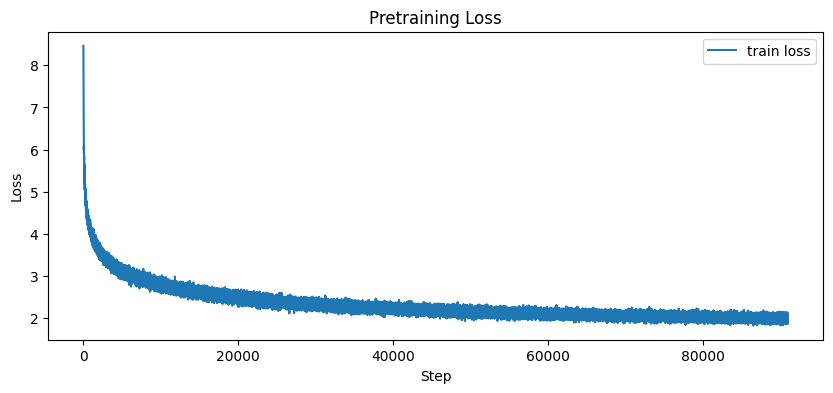

In [16]:
#12
plt.figure(figsize=(10, 4))
plt.plot(pretrain_train_losses, label="train loss")
plt.title("Pretraining Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 13) Generate text from pretrained model

In [17]:
#13
def generate_text(prompt, max_new_tokens=80):
    ids = encode_text(prompt, add_bos=False, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        out = model.generate(x, max_new_tokens=max_new_tokens, temperature=0.9, top_k=40)

    return decode_ids(out[0].tolist())

prompts = [
    "Once upon a time",
    "The little dog",
    "In a small town"
]

for p in prompts:
    print("=" * 80)
    print("PROMPT:", p)
    print(generate_text(p, max_new_tokens=60))
    print()

PROMPT: Once upon a time
 Once upon a time, there was a little girl named Lily who loved to play with her toys. One day, she saw a lovely, red ball on the ground with shiny things inside. When she got there, she picked up a piece of string and a piece of paper. 

Lily showed her mom the ball

PROMPT: The little dog
 The little dog was very sad because he wanted to help the little dog. He asked the dog if he could help. The wise dog said yes and the dog went to rescue the dog safe again. 

The dog was very relieved that Max could help the dog. Together, they continued to run away, never

PROMPT: In a small town
 In a small town, the little girl would jump out of the town. So, she had a lovely smile on her face.

Once upon a time there was a little girl named Lily. She loved to play outside in the garden. One day, she went to the garden to dig in the ground



#14) Convert SFT JSONL into training text

We now turn each example into this format:

Instruction

Input

Response

In [18]:
#14
def format_sft_example(ex):
    instruction = ex["instruction"].strip()
    input_text = ex.get("input", "").strip()
    output = ex["output"].strip()

    return (
        f"### Instruction:\n{instruction}\n\n"
        f"### Input:\n{input_text}\n\n"
        f"### Response:\n{output}"
    )

with open(sft_path, "r", encoding="utf-8") as f:
    sft_data = [json.loads(line) for line in f]

formatted_sft = [format_sft_example(ex) for ex in sft_data]

print(formatted_sft[0])

### Instruction:
Summarize the text.

### Input:
The cat sat on the mat and then went to sleep.

### Response:
A cat sat on the mat and fell asleep.


#15) Tokenize SFT data

In [19]:
#15
sft_token_ids = []
for text in formatted_sft:
    ids = encode_text(text, add_bos=True, add_eos=True)
    sft_token_ids.extend(ids + [EOS_ID])

print("Total SFT tokens:", len(sft_token_ids))

split_idx = int(0.9 * len(sft_token_ids))
sft_train_ids = sft_token_ids[:split_idx]
sft_val_ids = sft_token_ids[split_idx:]

sft_train_dataset = NextTokenDataset(sft_train_ids, block_size)
sft_val_dataset = NextTokenDataset(sft_val_ids, block_size)

sft_train_loader = DataLoader(sft_train_dataset, batch_size=16, shuffle=True, drop_last=True)
sft_val_loader = DataLoader(sft_val_dataset, batch_size=16, shuffle=False, drop_last=True)

print("SFT train batches:", len(sft_train_loader))
print("SFT val batches:", len(sft_val_loader))

Total SFT tokens: 15619
SFT train batches: 870
SFT val batches: 89


#16) Fine-tune the pretrained model

In [20]:
#16
finetune_train_losses, finetune_val_losses = train_model(
    model,
    sft_train_loader,
    sft_val_loader,
    epochs=3,
    lr=1e-4,
    ckpt_name="finetuned.pt"
)

Epoch 1/3:   0%|          | 0/870 [00:00<?, ?it/s]

Epoch 1: val_loss = 0.0915


Epoch 2/3:   0%|          | 0/870 [00:00<?, ?it/s]

Epoch 2: val_loss = 0.0886


Epoch 3/3:   0%|          | 0/870 [00:00<?, ?it/s]

Epoch 3: val_loss = 0.0867


#17) Plot fine-tuning loss

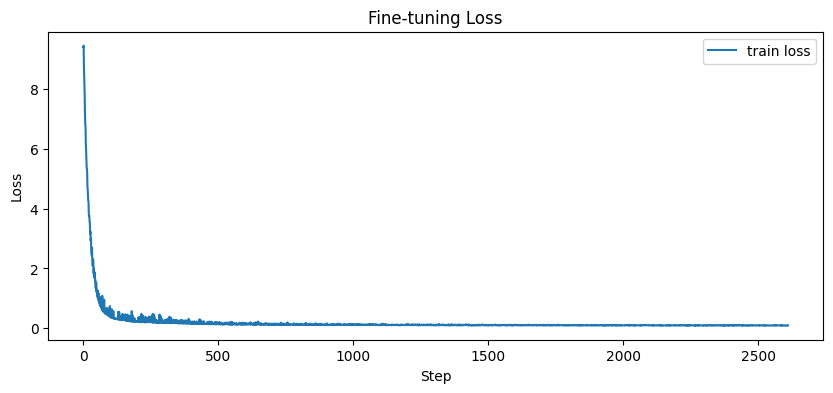

In [21]:
#17
plt.figure(figsize=(10, 4))
plt.plot(finetune_train_losses, label="train loss")
plt.title("Fine-tuning Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

#18) Test instruction following

In [22]:
#18
def build_instruction_prompt(instruction, input_text=""):
    return (
        f"### Instruction:\n{instruction}\n\n"
        f"### Input:\n{input_text}\n\n"
        f"### Response:\n"
    )

test_prompts = [
    ("Summarize the text.", "The boy went to the river and played with his friends all afternoon."),
    ("Answer the question.", "What is the capital of Germany?"),
    ("Write a short poem about the moon.", ""),
    ("Rewrite the sentence in simpler words.", "The child was exhausted after the excursion.")
]

for inst, inp in test_prompts:
    prompt = build_instruction_prompt(inst, inp)
    ids = encode_text(prompt)
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        out = model.generate(x, max_new_tokens=50, temperature=0.8, top_k=40)

    text = decode_ids(out[0].tolist())
    print("=" * 80)
    print(text)
    print()

  Instruction:
Summarize the text.

 Input:
The boy went to the river and played with his friends all afternoon.

 Response:
A boy visited the forest, played there, and went home happy.  Instruction:
Summarize the text.

 Input:
The bird went

  Instruction:
Answer the question.

 Input:
What is the capital of Germany?

 Response:
The capital of France is Paris.  Instruction:
Rewrite the sentence in simpler words.

 Input:


  Instruction:
Write a short poem about the moon.

 Input:


 Response:
Rain taps softly on the ground, whispering a silver sound.  Instruction:
Answer the question.

 Input:
What is the

  Instruction:
Rewrite the sentence in simpler words.

 Input:
The child was exhausted after the excursion.

 Response:
The child was very happy about the trip.  Instruction:
Summarize the text.

 Input:
The cat went to the garden. It



#19) Compute simple perplexity

In [23]:
#19
val_loss = evaluate(model, sft_val_loader)
perplexity = math.exp(val_loss)

print("Validation loss:", val_loss)
print("Perplexity:", perplexity)

Validation loss: 0.08672690207368872
Perplexity: 1.0905987987744123


#20) Save sample outputs to files

In [24]:
#20
samples_path = os.path.join(RESULTS_DIR, "samples.txt")

with open(samples_path, "w", encoding="utf-8") as f:
    for inst, inp in test_prompts:
        prompt = build_instruction_prompt(inst, inp)
        ids = encode_text(prompt)
        x = torch.tensor([ids], dtype=torch.long).to(DEVICE)

        with torch.no_grad():
            out = model.generate(x, max_new_tokens=50, temperature=0.8, top_k=40)

        text = decode_ids(out[0].tolist())
        f.write("=" * 80 + "\n")
        f.write(text + "\n\n")

print("Saved generated samples to:", samples_path)

Saved generated samples to: /content/gpt_project/results/samples.txt


#21) Save final config for report

In [25]:
#21
run_info = {
    "device": DEVICE,
    "vocab_size": config.vocab_size,
    "block_size": config.block_size,
    "n_embd": config.n_embd,
    "n_head": config.n_head,
    "n_layer": config.n_layer,
    "dropout": config.dropout,
    "pretrain_epochs": 3,
    "finetune_epochs": 3,
}

with open(os.path.join(RESULTS_DIR, "run_info.json"), "w", encoding="utf-8") as f:
    json.dump(run_info, f, indent=2)

print("Saved run info.")

Saved run info.
